# Setup

In [13]:
import sys

import configparser
from pathlib import Path
import pandas as pd
import numpy as np
from prophet import Prophet
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from catboost import CatBoostRegressor

In [14]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.optimizers import (
    tune_catboost,
    tune_prophet,
    tune_lightgbm,
    tune_lstm,
    tune_transformer,
    tune_arima,
)
from src.features import FeatureEngineering
from src.models import (
    CatBoostTrainer,
    ARIMATrainer,
    DeepLearningTrainer,
    HybridResidualModel,
)
from src.explainability import (
    explain_model,
    plot_feature_importance,
    plot_shap_summary,
    plot_partial_dependence,
)
from src.metrics import get_mae, get_rmse, get_mape, get_r2, evaluate_regression

import warnings

warnings.filterwarnings("ignore")

# Load Configuration File

In [15]:
# Đọc file config.ini
config = configparser.ConfigParser()
config.read(PROJECT_ROOT / "config.ini", encoding="utf-8")

# Khởi tạo các biến
DATA_DIR = PROJECT_ROOT / config.get("PATHS", "DATA_DIR")
TRAIN_FILE = PROJECT_ROOT / config.get("PATHS", "TRAIN_FILE")
TEST_FILE = PROJECT_ROOT / config.get("PATHS", "TEST_FILE")
OUT_FILE = PROJECT_ROOT / config.get("PATHS", "OUT_FILE")

split_date = pd.to_datetime(config["VALID"]["split_date"])

N_TRIALS = config.getint("SETTINGS", "N_TRIALS")
N_JOBS = config.getint("SETTINGS", "N_JOBS")
TARGET_COLS = [col.strip() for col in config.get("SETTINGS", "TARGET_COLS").split(",")]

# In kiểm tra
print(f"Project Root: {PROJECT_ROOT}")
print(f"Train File: {TRAIN_FILE}")
print(f"Test File: {TEST_FILE}")
print(f"Output directory: {OUT_FILE}")
print("\n","-" * 50, "\n")
print(f"Split date: {split_date}")
print("\n", "-" * 50, "\n")
print(f"n-trials = {N_TRIALS}")
print(f"n-jobs = {N_JOBS}")
print(f"Targets: {TARGET_COLS}")

Project Root: e:\Datathon26
Train File: e:\Datathon26\dataset\sales.csv
Test File: e:\Datathon26\dataset\sample_submission.csv
Output directory: e:\Datathon26\output\submission.csv

 -------------------------------------------------- 

Split date: 2022-01-01 00:00:00

 -------------------------------------------------- 

n-trials = 30
n-jobs = -1
Targets: ['Revenue', 'COGS']


# Split training data into train and validation sets

In [16]:
required_vars = [
    "train_data",
    "val_data",
    "train_processed",
    "val_processed",
    "feature_cols",
    "fe_pipeline",
]

if not all(v in globals() for v in required_vars):
    print("[Info] Missing preprocessing variables. Rebuilding pipeline...")

    train_df = pd.read_csv(TRAIN_FILE)
    train_df["Date"] = pd.to_datetime(train_df["Date"])
    train_df = train_df.sort_values("Date").reset_index(drop=True)

    fe_pipeline = FeatureEngineering(
        lag_periods=[7, 14, 30, 60], ema_windows=[7, 14, 30], fourier_orders=3
    )

    train_data = train_df[train_df["Date"] < split_date].copy()
    val_data = train_df[train_df["Date"] >= split_date].copy()

    fe_pipeline.fit(train_data)

    buffer_days = 120
    val_input = pd.concat([train_data.tail(buffer_days), val_data], ignore_index=True)

    train_processed = fe_pipeline.transform(train_data)
    val_processed_full = fe_pipeline.transform(val_input)

    val_processed = val_processed_full[val_processed_full["Date"] >= split_date].copy()

    feature_cols = [
        c for c in train_processed.columns if c not in ["Date", "Revenue", "COGS"]
    ]

# Fine-tuning models

Các mô hình được sử dụng:
- Gradient boosting (tree-based models)
    + Catboost
    + Catboost + fine-tune
    + LightGBM

- Deep Learning 
    + LSTM
    + Transformer 
- Classical TS models - ARIMA, Prophet
- Hybrid (LightGBM + Prophet)

In [17]:
# =====================================================
# MODELS (Optimized per Target)
# =====================================================
model_scores = {t: {} for t in TARGET_COLS}
best_params = {
    m: {t: {} for t in TARGET_COLS}
    for m in [
        "CatBoost",
        "CatBoost_Default",
        "Prophet",
        "LightGBM",
        "LSTM",
        "Transformer",
        "ARIMA",
    ]
}

In [18]:
# ---------- 0) CATBOOST DEFAULT (BASELINE) ----------
print("\n===== CATBOOST DEFAULT (BASELINE) =====")
for t in TARGET_COLS:
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        eval_metric="MAE",
        random_seed=42,
        verbose=0,
    )
    model.fit(
        train_processed[feature_cols],
        train_processed[t],
        eval_set=(val_processed[feature_cols], val_processed[t]),
        early_stopping_rounds=100,
    )
    pred = np.clip(model.predict(val_processed[feature_cols]), 0, None)
    model_scores[t]["CatBoost_Default"] = evaluate_regression(val_processed[t], pred)
    print(
        f"[CatBoost Default] {t}: "
        f"RMSE={model_scores[t]['CatBoost_Default']['RMSE']:.2f}"
    )


===== CATBOOST DEFAULT (BASELINE) =====
[CatBoost Default] Revenue: RMSE=774674.22
[CatBoost Default] COGS: RMSE=674402.56


In [19]:
# ---------- 1) CATBOOST OPTIMIZED ----------
print("\n===== CATBOOST OPTIMIZED =====")
for t in TARGET_COLS:
    params, score = tune_catboost(
        train_processed, feature_cols, t, n_trials=N_TRIALS, n_jobs=N_JOBS
    )
    best_params["CatBoost"][t] = params

    cb_params = params.copy()
    cb_params.update(
        {"loss_function": "RMSE", "eval_metric": "MAE", "verbose": 0, "random_seed": 42}
    )

    model = CatBoostRegressor(**cb_params)
    model.fit(
        train_processed[feature_cols],
        train_processed[t],
        eval_set=(val_processed[feature_cols], val_processed[t]),
        use_best_model=True,
    )

    pred = np.clip(model.predict(val_processed[feature_cols]), 0, None)
    model_scores[t]["CatBoost"] = evaluate_regression(val_processed[t], pred)
    print(f"[CatBoost Optimized] {t}: RMSE={model_scores[t]['CatBoost']['RMSE']:.2f}")

[I 2026-05-01 00:49:19,137] A new study created in memory with name: no-name-edb66487-3721-4786-a899-78ce2c1d6f6b



===== CATBOOST OPTIMIZED =====


[I 2026-05-01 00:49:26,457] Trial 4 finished with value: 1891937.1275310463 and parameters: {'iterations': 392, 'learning_rate': 0.0016041681154100376, 'depth': 4, 'l2_leaf_reg': 0.12288305609412943, 'subsample': 0.9823887967179399}. Best is trial 4 with value: 1891937.1275310463.
[I 2026-05-01 00:49:26,717] Trial 9 finished with value: 1619357.342022458 and parameters: {'iterations': 384, 'learning_rate': 0.0027937524696771544, 'depth': 4, 'l2_leaf_reg': 1.0900317947685023, 'subsample': 0.801142253413821}. Best is trial 9 with value: 1619357.342022458.
[I 2026-05-01 00:49:35,061] Trial 0 finished with value: 1990671.607851165 and parameters: {'iterations': 348, 'learning_rate': 0.0012364850476069675, 'depth': 6, 'l2_leaf_reg': 3.8171433141812927, 'subsample': 0.8564610795019881}. Best is trial 9 with value: 1619357.342022458.
[I 2026-05-01 00:49:47,984] Trial 17 finished with value: 769020.5420405708 and parameters: {'iterations': 439, 'learning_rate': 0.019007885205978823, 'depth': 6

[CatBoost Optimized] Revenue: RMSE=776749.27


[I 2026-05-01 00:53:32,352] Trial 15 finished with value: 750149.2290614804 and parameters: {'iterations': 760, 'learning_rate': 0.0063613411384612776, 'depth': 4, 'l2_leaf_reg': 0.34451684757452966, 'subsample': 0.6885423154819854}. Best is trial 15 with value: 750149.2290614804.
[I 2026-05-01 00:53:37,774] Trial 6 finished with value: 637593.3698820441 and parameters: {'iterations': 1196, 'learning_rate': 0.08975112872917677, 'depth': 4, 'l2_leaf_reg': 0.14430423272496026, 'subsample': 0.7546147865642991}. Best is trial 6 with value: 637593.3698820441.
[I 2026-05-01 00:53:39,168] Trial 2 finished with value: 674966.9175830684 and parameters: {'iterations': 445, 'learning_rate': 0.01486460098842462, 'depth': 6, 'l2_leaf_reg': 2.4951376754753647, 'subsample': 0.7906201940492641}. Best is trial 6 with value: 637593.3698820441.
[I 2026-05-01 00:53:40,300] Trial 10 finished with value: 642762.1629769893 and parameters: {'iterations': 1421, 'learning_rate': 0.08533760291069996, 'depth': 4,

[CatBoost Optimized] COGS: RMSE=647599.00


In [20]:
# ---------- 2) PROPHET ----------
print("\n===== PROPHET =====")
for t in TARGET_COLS:
    params, score = tune_prophet(
        train_data, "Date", t, n_trials=N_TRIALS, n_jobs=N_JOBS
    )
    best_params["Prophet"][t] = params

    p_train = train_data[["Date", t]].rename(columns={"Date": "ds", t: "y"})
    p_val = val_data[["Date"]].rename(columns={"Date": "ds"})

    pm = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        **params,
    )
    pm.fit(p_train)

    pred = np.clip(pm.predict(p_val)["yhat"].values, 0, None)
    model_scores[t]["Prophet"] = evaluate_regression(val_data[t], pred)
    print(f"[Prophet] {t}: RMSE={model_scores[t]['Prophet']['RMSE']:.2f}")

[I 2026-05-01 00:57:24,846] A new study created in memory with name: no-name-9839f1f2-241e-4bd2-9a9a-583261dd3288



===== PROPHET =====


00:57:26 - cmdstanpy - INFO - Chain [1] start processing
00:57:26 - cmdstanpy - INFO - Chain [1] start processing
00:57:26 - cmdstanpy - INFO - Chain [1] start processing
00:57:26 - cmdstanpy - INFO - Chain [1] start processing
00:57:26 - cmdstanpy - INFO - Chain [1] done processing
00:57:26 - cmdstanpy - INFO - Chain [1] done processing
00:57:26 - cmdstanpy - INFO - Chain [1] done processing
00:57:26 - cmdstanpy - INFO - Chain [1] done processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain [1] start processing
00:57:27 - cmdstanpy - INFO - Chain

[Prophet] Revenue: RMSE=1796211.31


00:57:34 - cmdstanpy - INFO - Chain [1] start processing
00:57:34 - cmdstanpy - INFO - Chain [1] done processing
00:57:34 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] done processing
00:57:35 - cmdstanpy - INFO - Chain [1] done processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] done processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] start processing
00:57:35 - cmdstanpy - INFO - Chain [1] done processing
00:57:35 - cmdstanpy - INFO - Chain 

[Prophet] COGS: RMSE=1540600.32


In [21]:
# ---------- 3) LIGHTGBM ----------
print("\n===== LIGHTGBM =====")
for t in TARGET_COLS:
    params, score = tune_lightgbm(
        train_processed, feature_cols, t, n_trials=N_TRIALS, n_jobs=N_JOBS
    )
    best_params["LightGBM"][t] = params

    model = lgb.LGBMRegressor(**params, random_state=42, verbosity=-1)
    model.fit(train_processed[feature_cols], train_processed[t])

    pred = np.clip(model.predict(val_processed[feature_cols]), 0, None)
    model_scores[t]["LightGBM"] = evaluate_regression(val_processed[t], pred)
    print(f"[LightGBM] {t}: RMSE={model_scores[t]['LightGBM']['RMSE']:.2f}")

[I 2026-05-01 00:57:40,574] A new study created in memory with name: no-name-17e86850-1f4a-40cc-adfb-2848ab3de625



===== LIGHTGBM =====


[I 2026-05-01 00:57:43,665] Trial 5 finished with value: 805103.0330954555 and parameters: {'n_estimators': 369, 'learning_rate': 0.046522300401960696, 'max_depth': 8, 'num_leaves': 168, 'min_child_samples': 74, 'subsample': 0.6250464692047075, 'colsample_bytree': 0.5692504349593133, 'reg_alpha': 0.0001070597714080544, 'reg_lambda': 8.451077655740049}. Best is trial 5 with value: 805103.0330954555.
[I 2026-05-01 00:57:44,083] Trial 9 finished with value: 780188.4205941077 and parameters: {'n_estimators': 630, 'learning_rate': 0.08803029366430451, 'max_depth': 5, 'num_leaves': 112, 'min_child_samples': 64, 'subsample': 0.9497193234318667, 'colsample_bytree': 0.5762384472696942, 'reg_alpha': 0.3387554990814873, 'reg_lambda': 0.006931017782788773}. Best is trial 9 with value: 780188.4205941077.
[I 2026-05-01 00:57:44,251] Trial 12 finished with value: 854158.4983118833 and parameters: {'n_estimators': 397, 'learning_rate': 0.014751781507716374, 'max_depth': 9, 'num_leaves': 245, 'min_chil

[LightGBM] Revenue: RMSE=822843.34


[I 2026-05-01 00:58:08,628] Trial 1 finished with value: 733638.9093024295 and parameters: {'n_estimators': 315, 'learning_rate': 0.014803471579886813, 'max_depth': 6, 'num_leaves': 18, 'min_child_samples': 83, 'subsample': 0.9452053958788433, 'colsample_bytree': 0.815071881944142, 'reg_alpha': 0.0009204563507734356, 'reg_lambda': 0.17533823031222592}. Best is trial 1 with value: 733638.9093024295.
[I 2026-05-01 00:58:09,569] Trial 2 finished with value: 1616708.8462356962 and parameters: {'n_estimators': 352, 'learning_rate': 0.0010682643212421158, 'max_depth': 12, 'num_leaves': 137, 'min_child_samples': 98, 'subsample': 0.8693540044071704, 'colsample_bytree': 0.9345052156555396, 'reg_alpha': 0.0014079613063306745, 'reg_lambda': 0.23952396283286556}. Best is trial 1 with value: 733638.9093024295.
[I 2026-05-01 00:58:09,766] Trial 5 finished with value: 693770.0729924351 and parameters: {'n_estimators': 892, 'learning_rate': 0.027142496702251075, 'max_depth': 4, 'num_leaves': 73, 'min_

[LightGBM] COGS: RMSE=709413.66


In [22]:
# ---------- 4) LSTM ----------
print("\n===== LSTM =====")
for t in TARGET_COLS:
    params, score = tune_lstm(
        train_processed, feature_cols, t, seq_len=14, n_trials=N_TRIALS, n_jobs=N_JOBS
    )
    best_params["LSTM"][t] = params

    trainer = DeepLearningTrainer(model_type="lstm", target_cols=[t], seq_len=14)
    trainer.fit(train_processed, feature_cols, model_params=params)

    preds_df = trainer.predict(
        train_processed, val_data["Date"].tolist(), feature_cols, fe_pipeline
    )
    model_scores[t]["LSTM"] = evaluate_regression(val_data[t], preds_df[t])
    print(f"[LSTM] {t}: RMSE={model_scores[t]['LSTM']['RMSE']:.2f}")


===== LSTM =====


[I 2026-05-01 00:58:39,898] A new study created in memory with name: no-name-3af53976-a1ae-477a-8ade-21bcc0898fd5
[I 2026-05-01 00:58:52,389] Trial 2 finished with value: 826766.0341450952 and parameters: {'hidden_dim': 224, 'num_layers': 1, 'lr': 0.0006690921338010971, 'batch_size': 32, 'epochs': 10}. Best is trial 2 with value: 826766.0341450952.
[I 2026-05-01 00:58:52,611] Trial 15 finished with value: 1027735.6474435779 and parameters: {'hidden_dim': 96, 'num_layers': 3, 'lr': 0.0008506597623077074, 'batch_size': 64, 'epochs': 16}. Best is trial 2 with value: 826766.0341450952.
[I 2026-05-01 00:59:04,101] Trial 0 finished with value: 804731.226822328 and parameters: {'hidden_dim': 192, 'num_layers': 1, 'lr': 0.0005337803074597071, 'batch_size': 32, 'epochs': 20}. Best is trial 0 with value: 804731.226822328.
[I 2026-05-01 00:59:08,721] Trial 1 finished with value: 834928.1777983673 and parameters: {'hidden_dim': 160, 'num_layers': 3, 'lr': 0.0002409377142061796, 'batch_size': 32, '

Khởi tạo LSTM trên thiết bị: cuda
Đang huấn luyện LSTM cho Revenue...
Epoch [10/24], Loss: 0.002115
Epoch [20/24], Loss: 0.001368
Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Enco

[I 2026-05-01 01:01:49,774] A new study created in memory with name: no-name-d869e3dd-4152-4850-bbcc-876dd6edf121
[I 2026-05-01 01:02:02,648] Trial 4 finished with value: 728818.688391222 and parameters: {'hidden_dim': 192, 'num_layers': 1, 'lr': 0.006383835546501115, 'batch_size': 64, 'epochs': 22}. Best is trial 4 with value: 728818.688391222.
[I 2026-05-01 01:02:04,127] Trial 7 finished with value: 736370.6352986166 and parameters: {'hidden_dim': 160, 'num_layers': 1, 'lr': 0.00019602627369746448, 'batch_size': 32, 'epochs': 13}. Best is trial 4 with value: 728818.688391222.
[I 2026-05-01 01:02:06,262] Trial 2 finished with value: 743931.4899624155 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'lr': 0.00025455892362484306, 'batch_size': 16, 'epochs': 12}. Best is trial 4 with value: 728818.688391222.
[I 2026-05-01 01:02:13,036] Trial 17 finished with value: 648942.4353170481 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.004401659905246394, 'batch_size': 32, 'epo

Khởi tạo LSTM trên thiết bị: cuda
Đang huấn luyện LSTM cho COGS...
Epoch [10/23], Loss: 0.003071
Epoch [20/23], Loss: 0.001814
Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encodin

In [23]:
# ---------- 5) TRANSFORMER ----------
print("\n===== TRANSFORMER =====")
for t in TARGET_COLS:
    params, score = tune_transformer(
        train_processed, feature_cols, t, seq_len=14, n_trials=N_TRIALS, n_jobs=N_JOBS
    )
    best_params["Transformer"][t] = params

    trainer = DeepLearningTrainer(model_type="transformer", target_cols=[t], seq_len=14)
    trainer.fit(train_processed, feature_cols, model_params=params)

    preds_df = trainer.predict(
        train_processed, val_data["Date"].tolist(), feature_cols, fe_pipeline
    )
    model_scores[t]["Transformer"] = evaluate_regression(val_data[t], preds_df[t])
    print(f"[Transformer] {t}: RMSE={model_scores[t]['Transformer']['RMSE']:.2f}")

[I 2026-05-01 01:05:27,230] A new study created in memory with name: no-name-424d825d-66c2-4a42-a5bd-bdd557a03de4



===== TRANSFORMER =====


[I 2026-05-01 01:05:48,999] Trial 3 finished with value: 946763.8109383965 and parameters: {'d_model': 64, 'nhead': 4, 'num_layers': 3, 'lr': 0.00015298911059206252, 'batch_size': 64, 'epochs': 14}. Best is trial 3 with value: 946763.8109383965.
[I 2026-05-01 01:06:07,757] Trial 16 finished with value: 1978708.3363387869 and parameters: {'d_model': 64, 'nhead': 8, 'num_layers': 2, 'lr': 0.0016728942887498598, 'batch_size': 64, 'epochs': 15}. Best is trial 3 with value: 946763.8109383965.
[I 2026-05-01 01:06:08,363] Trial 5 finished with value: 2584230.673679426 and parameters: {'d_model': 256, 'nhead': 2, 'num_layers': 3, 'lr': 0.003297760013936984, 'batch_size': 32, 'epochs': 15}. Best is trial 3 with value: 946763.8109383965.
[I 2026-05-01 01:06:35,706] Trial 12 finished with value: 971191.6830426683 and parameters: {'d_model': 32, 'nhead': 2, 'num_layers': 4, 'lr': 0.000220752048431002, 'batch_size': 64, 'epochs': 32}. Best is trial 3 with value: 946763.8109383965.
[I 2026-05-01 01:

Khởi tạo TRANSFORMER trên thiết bị: cuda
Đang huấn luyện TRANSFORMER cho Revenue...
Epoch [10/18], Loss: 0.003867
Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical

[I 2026-05-01 01:12:20,963] A new study created in memory with name: no-name-cfd62659-f2fa-4e3b-b2ac-232cbfcb3a55


Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering h

[I 2026-05-01 01:12:47,685] Trial 3 finished with value: 1159171.2840336068 and parameters: {'d_model': 32, 'nhead': 1, 'num_layers': 2, 'lr': 0.0001260102006548816, 'batch_size': 32, 'epochs': 10}. Best is trial 3 with value: 1159171.2840336068.
[I 2026-05-01 01:13:10,167] Trial 0 finished with value: 743955.305750697 and parameters: {'d_model': 128, 'nhead': 4, 'num_layers': 3, 'lr': 0.0002644599379239321, 'batch_size': 16, 'epochs': 13}. Best is trial 0 with value: 743955.305750697.
[I 2026-05-01 01:13:32,125] Trial 17 finished with value: 920524.1022397337 and parameters: {'d_model': 128, 'nhead': 8, 'num_layers': 4, 'lr': 0.001801947992072052, 'batch_size': 64, 'epochs': 14}. Best is trial 0 with value: 743955.305750697.
[I 2026-05-01 01:13:57,494] Trial 16 finished with value: 793073.5231006101 and parameters: {'d_model': 32, 'nhead': 8, 'num_layers': 3, 'lr': 0.0013445860688301356, 'batch_size': 16, 'epochs': 17}. Best is trial 0 with value: 743955.305750697.
[I 2026-05-01 01:14

Khởi tạo TRANSFORMER trên thiết bị: cuda
Đang huấn luyện TRANSFORMER cho COGS...
Epoch [10/13], Loss: 0.003740
Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Ma

In [24]:
# ---------- 6) ARIMA ----------
print("\n===== ARIMA =====")
for t in TARGET_COLS:
    params, score = tune_arima(train_data, t, n_trials=N_TRIALS, n_jobs=N_JOBS)
    best_params["ARIMA"][t] = params

    order = (int(params["p"]), int(params["d"]), int(params["q"]))
    model = ARIMA(train_data[t].values, order=order).fit()

    pred = np.clip(model.forecast(steps=len(val_data)), 0, None)
    model_scores[t]["ARIMA"] = evaluate_regression(val_data[t], pred)
    print(f"[ARIMA] {t}: RMSE={model_scores[t]['ARIMA']['RMSE']:.2f}")

[I 2026-05-01 01:19:17,181] A new study created in memory with name: no-name-b6364d27-04c1-4649-8c9e-24c9ee67b3b8



===== ARIMA =====


[I 2026-05-01 01:19:22,633] Trial 1 finished with value: 2236756.367356819 and parameters: {'p': 0, 'd': 1, 'q': 1}. Best is trial 1 with value: 2236756.367356819.
[I 2026-05-01 01:19:24,302] Trial 3 finished with value: 2100734.0145297525 and parameters: {'p': 1, 'd': 1, 'q': 1}. Best is trial 3 with value: 2100734.0145297525.
[I 2026-05-01 01:19:31,196] Trial 13 finished with value: 2435927.2889822205 and parameters: {'p': 3, 'd': 0, 'q': 0}. Best is trial 3 with value: 2100734.0145297525.
[I 2026-05-01 01:19:32,219] Trial 6 finished with value: 2088527.7368840156 and parameters: {'p': 0, 'd': 1, 'q': 6}. Best is trial 6 with value: 2088527.7368840156.
[I 2026-05-01 01:19:36,070] Trial 5 finished with value: 2289175.0251145177 and parameters: {'p': 5, 'd': 1, 'q': 3}. Best is trial 6 with value: 2088527.7368840156.
[I 2026-05-01 01:19:36,312] Trial 0 finished with value: 2091674.5664806312 and parameters: {'p': 3, 'd': 1, 'q': 5}. Best is trial 6 with value: 2088527.7368840156.
[I 20

[ARIMA] Revenue: RMSE=2123129.27


[I 2026-05-01 01:20:07,261] Trial 3 finished with value: 2071924.6579518577 and parameters: {'p': 0, 'd': 0, 'q': 0}. Best is trial 3 with value: 2071924.6579518577.
[I 2026-05-01 01:20:07,929] Trial 10 finished with value: 2071924.6579518577 and parameters: {'p': 0, 'd': 0, 'q': 0}. Best is trial 3 with value: 2071924.6579518577.
[I 2026-05-01 01:20:17,830] Trial 13 finished with value: 7855367.70223965 and parameters: {'p': 5, 'd': 2, 'q': 0}. Best is trial 3 with value: 2071924.6579518577.
[I 2026-05-01 01:20:18,073] Trial 1 finished with value: 1835156.150711511 and parameters: {'p': 0, 'd': 1, 'q': 6}. Best is trial 1 with value: 1835156.150711511.
[I 2026-05-01 01:20:18,837] Trial 2 finished with value: 2008238.8658979305 and parameters: {'p': 6, 'd': 1, 'q': 0}. Best is trial 1 with value: 1835156.150711511.
[I 2026-05-01 01:20:26,354] Trial 15 finished with value: 2046451.7487692055 and parameters: {'p': 8, 'd': 1, 'q': 0}. Best is trial 1 with value: 1835156.150711511.
[I 2026

[ARIMA] COGS: RMSE=1603263.13


In [25]:
# ---------- 7) HYBRID RESIDUAL MODEL (NO TUNING) ----------
print("\n===== HYBRID RESIDUAL MODEL (NO TUNING) =====")

hybrid_model = HybridResidualModel(date_col="Date", target_cols=TARGET_COLS)

# fit
hybrid_model.fit(train_processed, feature_cols)

# evaluate
hybrid_metrics = hybrid_model.evaluate(val_processed)

for t in TARGET_COLS:
    model_scores[t]["Hybrid"] = hybrid_metrics[t]


===== HYBRID RESIDUAL MODEL (NO TUNING) =====

========== TRAIN Revenue ==========


01:21:08 - cmdstanpy - INFO - Chain [1] start processing
01:21:08 - cmdstanpy - INFO - Chain [1] done processing



========== TRAIN COGS ==========


01:21:10 - cmdstanpy - INFO - Chain [1] start processing
01:21:10 - cmdstanpy - INFO - Chain [1] done processing



Hybrid training completed.


========== EVALUATE Revenue ==========
MAE  : 685046.15
RMSE : 892284.86
MAPE : 23.62%
R2   : 0.7158

========== EVALUATE COGS ==========
MAE  : 567953.15
RMSE : 736074.46
MAPE : 22.41%
R2   : 0.7453


# Model Ranking

In [26]:
print("\n" + "=" * 60)
print("FINAL MODEL RANKING PER TARGET")
print("=" * 60)

for t in TARGET_COLS:
    rows = []

    for model_name, metrics in model_scores[t].items():
        rows.append(
            {
                "Model": model_name,
                "MAE": metrics.get("MAE", np.nan),
                "RMSE": metrics.get("RMSE", np.nan),
                "MAPE": metrics.get("MAPE", np.nan),
                "R2": metrics.get("R2", np.nan),
            }
        )

    df_rank = pd.DataFrame(rows)

    # sort by RMSE ascending (best first)
    df_rank = df_rank.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

    print(f"\n>>> Ranking for {t}:")
    print(df_rank)

    best_model = df_rank.iloc[0]["Model"]
    best_score = df_rank.iloc[0]["RMSE"]

    print(f"\n🏆 BEST for {t}: {best_model} | RMSE: {best_score:.2f}")


FINAL MODEL RANKING PER TARGET

>>> Ranking for Revenue:
              Model           MAE          RMSE       MAPE        R2
0  CatBoost_Default  6.025845e+05  7.746742e+05  25.184866  0.785797
1          CatBoost  6.001841e+05  7.767493e+05  24.565779  0.784648
2          LightGBM  6.368707e+05  8.228433e+05  27.430566  0.758330
3            Hybrid  6.850462e+05  8.922849e+05  23.616578  0.715819
4              LSTM  8.673502e+05  1.185817e+06  25.128402  0.498093
5       Transformer  1.053783e+06  1.390080e+06  39.062051  0.310288
6           Prophet  1.290420e+06  1.796211e+06  35.594855 -0.151602
7             ARIMA  1.519176e+06  2.123129e+06  41.385803 -0.608943

🏆 BEST for Revenue: CatBoost_Default | RMSE: 774674.22

>>> Ranking for COGS:
              Model           MAE          RMSE       MAPE        R2
0          CatBoost  4.900783e+05  6.475990e+05  22.314793  0.802867
1  CatBoost_Default  5.206648e+05  6.744026e+05  24.715843  0.786211
2          LightGBM  5.408947e+05  

# Predicting Revenue and COGS using the best 2 models

In [27]:
# =====================================================
# PREDICTION (Sync with Training Variables)
# =====================================================
print(f"\n{'='*60}")
print("Making predictions with best models per target")
print(f"{'='*60}")

# 1. Load test data
test_df = pd.read_csv(TEST_FILE)
test_df["Date"] = pd.to_datetime(test_df["Date"])
test_df = test_df.sort_values("Date").reset_index(drop=True)

# 2. Feature engineering
test_processed = fe_pipeline.transform(test_df)

# 3. Initialize predictions dataframe
test_predictions = pd.DataFrame({"Date": test_df["Date"].values})

# 4. Predict for each target using its specific best model
test_metrics = {}
test_rows = []
for t in TARGET_COLS:
    # Tự động lấy model tốt nhất từ kết quả ranking
    sorted_scores = sorted(
    model_scores[t].items(),
    key=lambda x: x[1]["RMSE"]
    )

    best_model_name, best_metrics = sorted_scores[0]
    best_score = best_metrics["RMSE"]

    print(
        f"-> Predicting {t} using {best_model_name} "
        f"(Val RMSE: {best_score:.2f})..."
    )
    if "CatBoost" in best_model_name:
        if best_model_name == "CatBoost_Default":
            model = CatBoostRegressor(
                iterations=1000,
                learning_rate=0.03,
                depth=6,
                loss_function="RMSE",
                eval_metric="MAE",
                random_seed=42,
                verbose=0,
            )
        else:
            params = best_params["CatBoost"][t]
            cb_params = params.copy()
            cb_params.update(
                {
                    "loss_function": "RMSE",
                    "eval_metric": "MAE",
                    "verbose": 0,
                    "random_seed": 42,
                }
            )
            model = CatBoostRegressor(**cb_params)
        model.fit(train_processed[feature_cols], train_processed[t])
        test_predictions[t] = np.clip(
            model.predict(test_processed[feature_cols]), 0, None
        )

    elif best_model_name == "Prophet":
        params = best_params["Prophet"][t]
        p_train = train_data[["Date", t]].rename(columns={"Date": "ds", t: "y"})
        p_test = test_df[["Date"]].rename(columns={"Date": "ds"})
        pm = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            **params,
        )
        pm.fit(p_train)
        test_predictions[t] = np.clip(pm.predict(p_test)["yhat"].values, 0, None)

    elif best_model_name == "LightGBM":
        params = best_params["LightGBM"][t]
        model = lgb.LGBMRegressor(**params, random_state=42, verbosity=-1)
        model.fit(train_processed[feature_cols], train_processed[t])
        test_predictions[t] = np.clip(
            model.predict(test_processed[feature_cols]), 0, None
        )

    elif best_model_name in ["LSTM", "Transformer"]:
        params = best_params[best_model_name][t]
        trainer = DeepLearningTrainer(
            model_type=best_model_name.lower(), target_cols=[t], seq_len=14
        )
        trainer.fit(train_processed, feature_cols, model_params=params)
        preds_df = trainer.predict(
            train_processed, test_df["Date"].tolist(), feature_cols, fe_pipeline
        )
        test_predictions[t] = np.clip(preds_df[t].values, 0, None)

    elif best_model_name == "ARIMA":
        params = best_params["ARIMA"][t]
        order = (int(params["p"]), int(params["d"]), int(params["q"]))
        model = ARIMA(train_data[t].values, order=order).fit()
        test_predictions[t] = np.clip(model.forecast(steps=len(test_df)), 0, None)

    # --- Metrics ---
    y_true = test_df[t]
    y_pred = test_predictions[t]

    metrics = evaluate_regression(y_true, y_pred)

    test_metrics[t] = metrics

    test_rows.append({
        "Target": t,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE": metrics["MAPE"],
        "R2": metrics["R2"],
    })
    df_test_metrics = pd.DataFrame(test_rows)

    df_test_metrics = df_test_metrics.sort_values(
        by="RMSE",
        ascending=True
    ).reset_index(drop=True)
    print("\n----------- Metrics of {t} ----------\n")
    print(df_test_metrics)
    print("\n","-"*37,"\n")
# 5. Save output
test_predictions.to_csv(OUT_FILE, index=False)
print(f"\nPredictions saved to: {OUT_FILE}")


Making predictions with best models per target
Đang tạo Time features...
Đang tạo Historical features (Lag, Diff, EMA)...
Đang Map Target Encoding (Historical Mapping)...
Feature engineering hoàn tất!

-> Predicting Revenue using CatBoost_Default (Val RMSE: 774674.22)...

----------- Metrics of {t} ----------

    Target            MAE           RMSE       MAPE        R2
0  Revenue  447379.791164  550137.257498  16.997656  0.878804

 ------------------------------------- 

-> Predicting COGS using CatBoost (Val RMSE: 647599.00)...

----------- Metrics of {t} ----------

    Target            MAE           RMSE       MAPE        R2
0     COGS  347881.545743  448071.450889  14.430236  0.891310
1  Revenue  447379.791164  550137.257498  16.997656  0.878804

 ------------------------------------- 


Predictions saved to: e:\Datathon26\output\submission.csv


# Models explainanility


INTERPRETING BEST MODELS PER TARGET

>>> Analysis for REVENUE (Best Model: CatBoost_Default):
Explaining model for Revenue

1. Feature Importance:


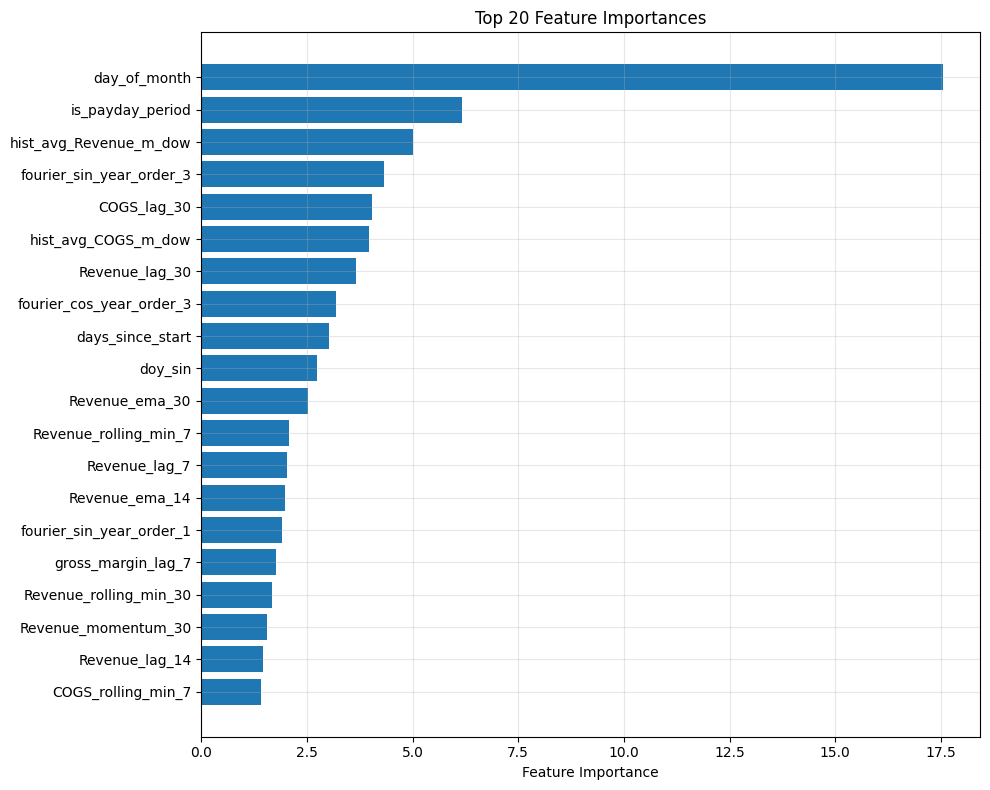


Top Feature Importances:
1. day_of_month: 17.550
2. is_payday_period: 6.176
3. hist_avg_Revenue_m_dow: 5.006
4. fourier_sin_year_order_3: 4.326
5. COGS_lag_30: 4.032
6. hist_avg_COGS_m_dow: 3.981
7. Revenue_lag_30: 3.674
8. fourier_cos_year_order_3: 3.179
9. days_since_start: 3.023
10. doy_sin: 2.736
11. Revenue_ema_30: 2.528
12. Revenue_rolling_min_7: 2.067
13. Revenue_lag_7: 2.033
14. Revenue_ema_14: 1.982
15. fourier_sin_year_order_1: 1.907
16. gross_margin_lag_7: 1.764
17. Revenue_rolling_min_30: 1.663
18. Revenue_momentum_30: 1.559
19. Revenue_lag_14: 1.465
20. COGS_rolling_min_7: 1.423

2. SHAP Analysis:


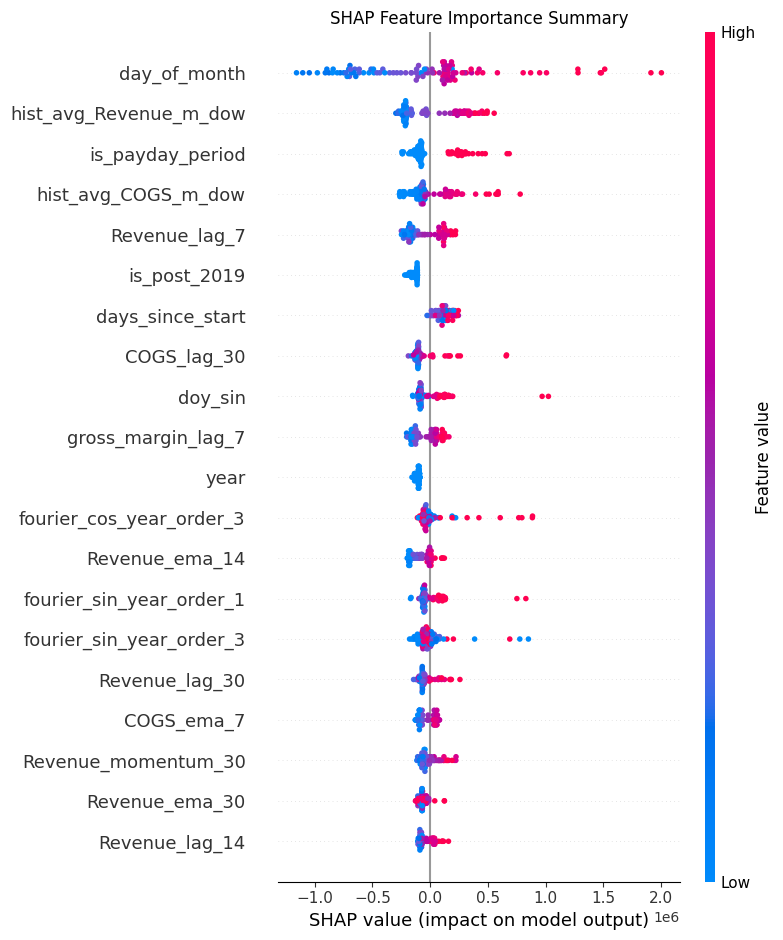


3. Partial Dependence Plots:

PDP for day_of_month:


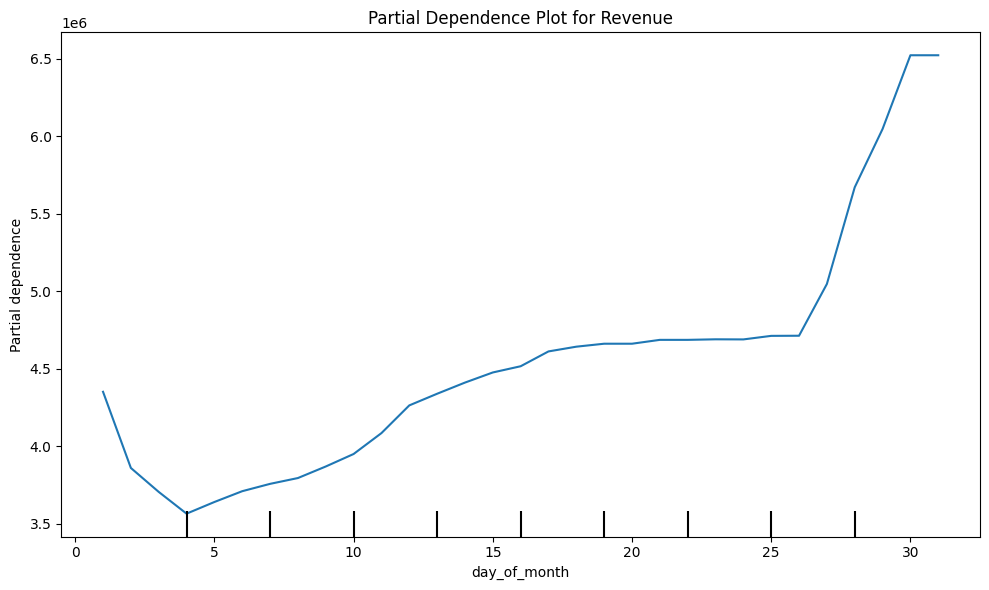


PDP for is_payday_period:


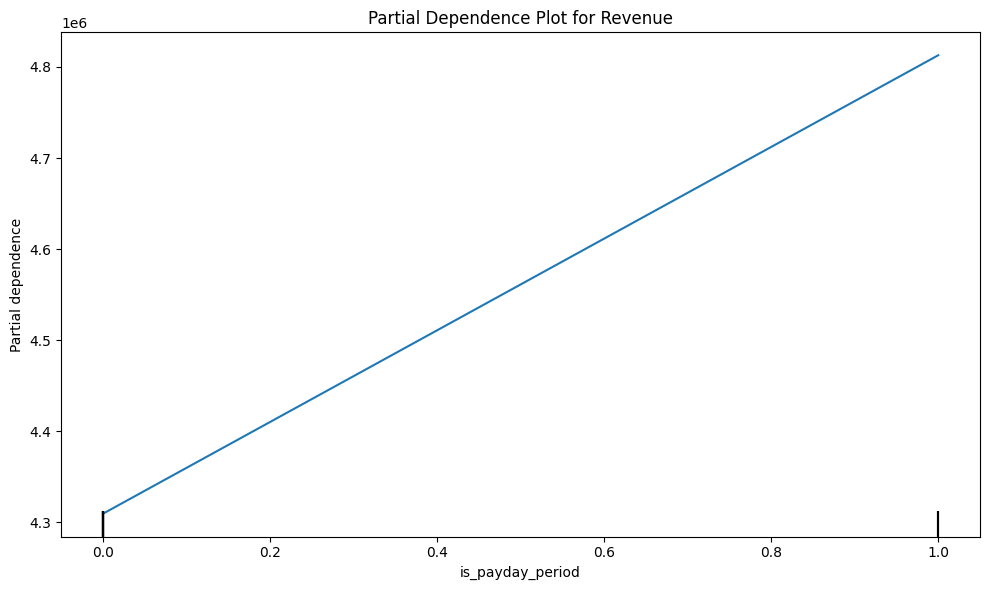


PDP for hist_avg_Revenue_m_dow:


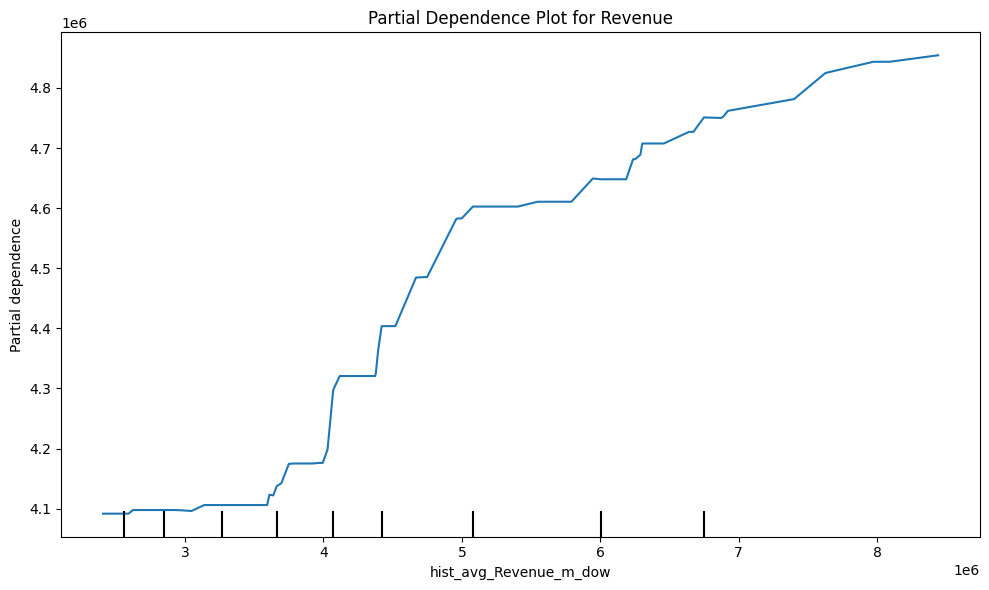


Model explanation complete!

>>> Analysis for COGS (Best Model: CatBoost):
Explaining model for COGS

1. Feature Importance:


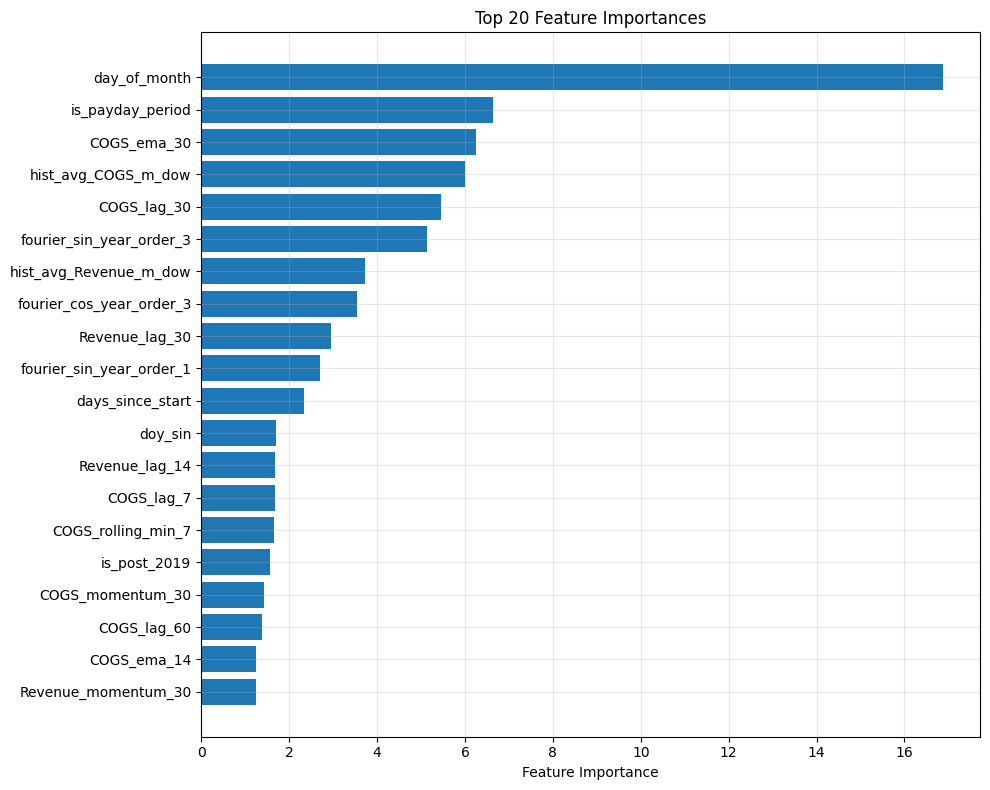


Top Feature Importances:
1. day_of_month: 16.874
2. is_payday_period: 6.630
3. COGS_ema_30: 6.260
4. hist_avg_COGS_m_dow: 6.001
5. COGS_lag_30: 5.454
6. fourier_sin_year_order_3: 5.128
7. hist_avg_Revenue_m_dow: 3.728
8. fourier_cos_year_order_3: 3.534
9. Revenue_lag_30: 2.945
10. fourier_sin_year_order_1: 2.701
11. days_since_start: 2.332
12. doy_sin: 1.695
13. Revenue_lag_14: 1.683
14. COGS_lag_7: 1.670
15. COGS_rolling_min_7: 1.651
16. is_post_2019: 1.576
17. COGS_momentum_30: 1.430
18. COGS_lag_60: 1.382
19. COGS_ema_14: 1.257
20. Revenue_momentum_30: 1.237

2. SHAP Analysis:


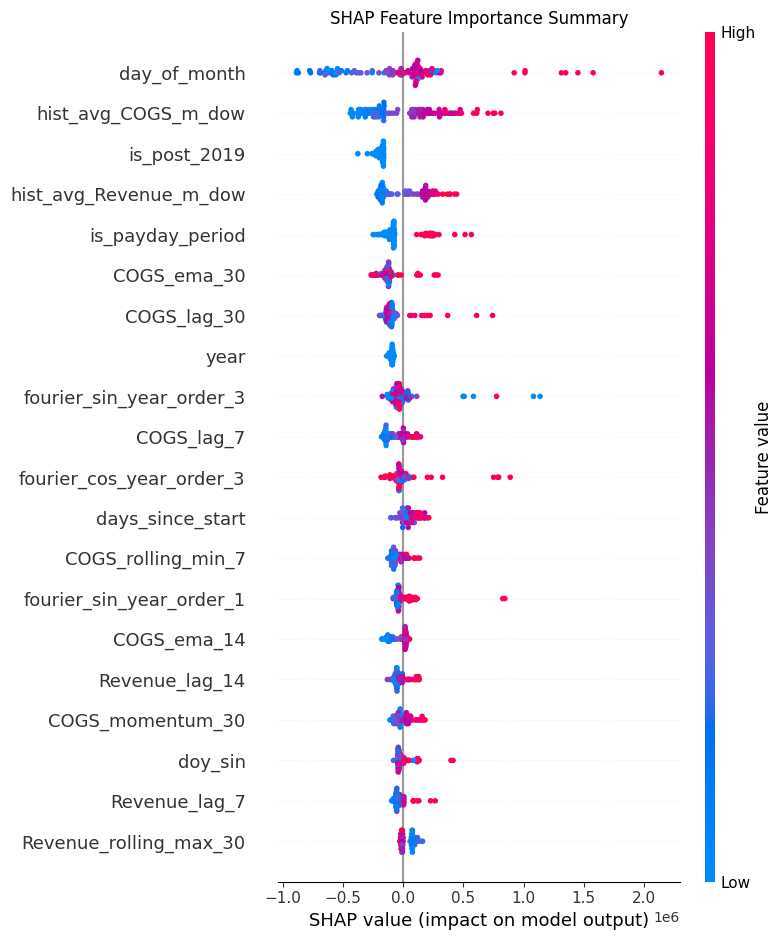


3. Partial Dependence Plots:

PDP for day_of_month:


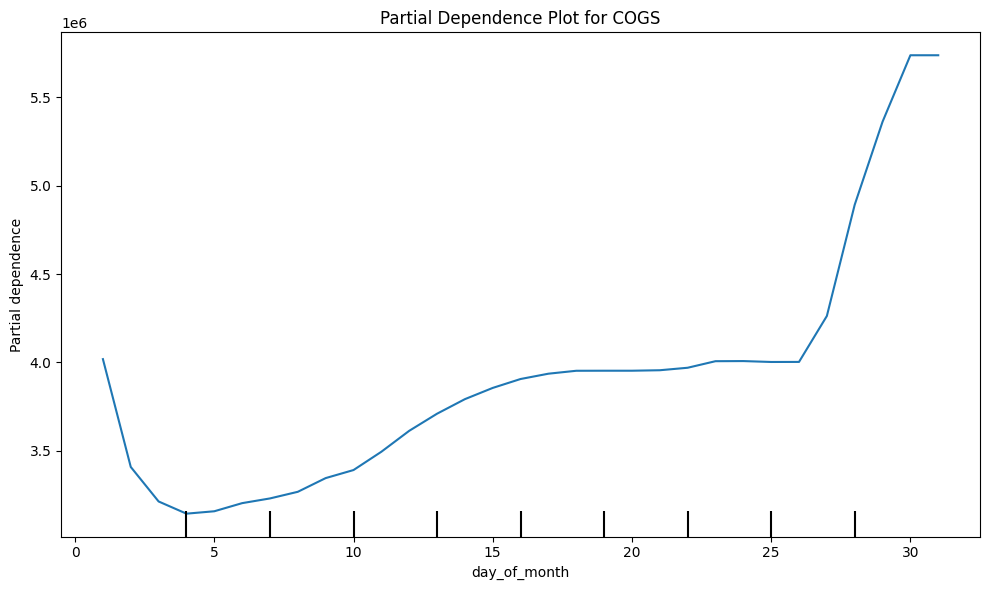


PDP for is_payday_period:


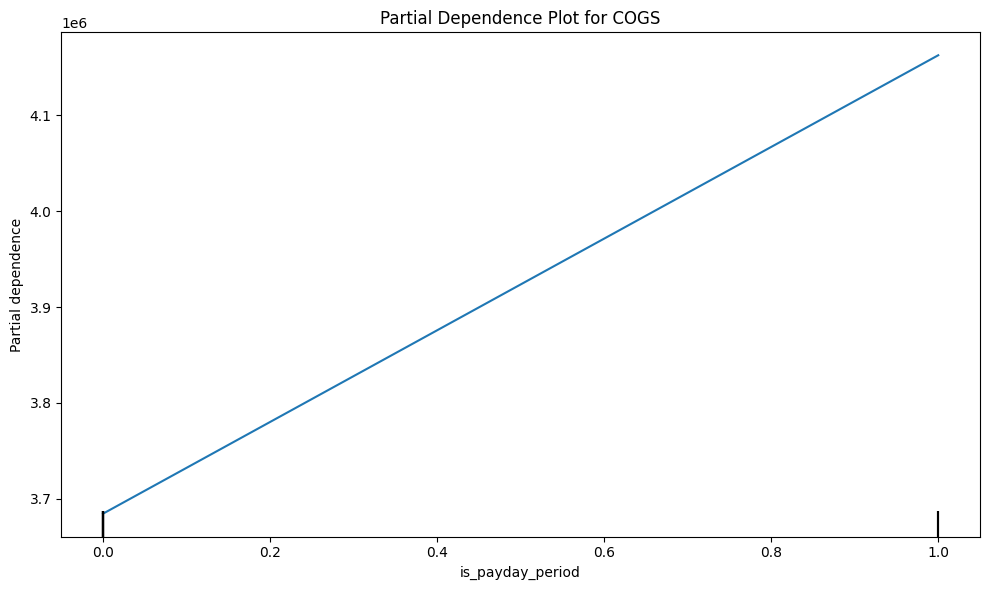


PDP for COGS_ema_30:


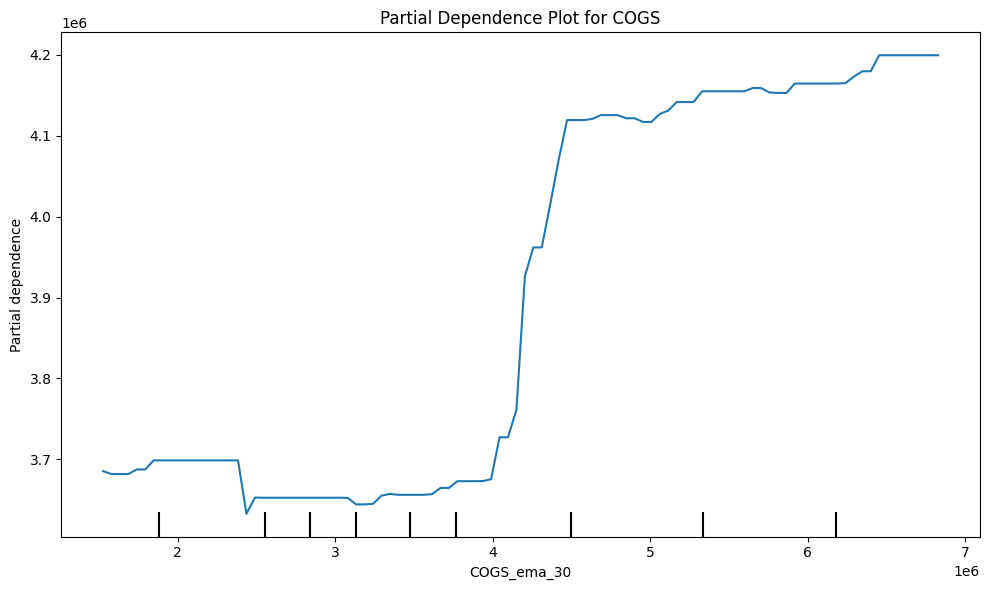


Model explanation complete!


In [28]:
# =====================================================
# EXPLAINING THE BEST MODELS (PER TARGET)
# =====================================================
print("\n" + "=" * 60)
print("INTERPRETING BEST MODELS PER TARGET")
print("=" * 60)

for target in TARGET_COLS:
    # Tự động lấy model tốt nhất cho target hiện tại từ kết quả ranking
    sorted_scores = sorted(
        model_scores[target].items(),
        key=lambda x: x[1]["RMSE"]
    )
    best_model_name, best_metrics = sorted_scores[0]

    print(f"\n>>> Analysis for {target.upper()} (Best Model: {best_model_name}):")

    model_obj = None

    # 1. Nếu Best Model là LightGBM
    if best_model_name == "LightGBM":
        params = best_params["LightGBM"][target]
        model_obj = lgb.LGBMRegressor(**params, random_state=42, verbosity=-1)
        model_obj.fit(train_processed[feature_cols], train_processed[target])

    # 2. Nếu Best Model là CatBoost (Optimized hoặc Default)
    elif "CatBoost" in best_model_name:
        if best_model_name == "CatBoost_Default":
            model_obj = CatBoostRegressor(
                iterations=1000,
                learning_rate=0.03,
                depth=6,
                loss_function="RMSE",
                eval_metric="MAE",
                random_seed=42,
                verbose=0,
            )
        else:
            params = best_params["CatBoost"][target]
            cb_params = params.copy()
            cb_params.update(
                {
                    "loss_function": "RMSE",
                    "eval_metric": "MAE",
                    "verbose": 0,
                    "random_seed": 42,
                }
            )
            model_obj = CatBoostRegressor(**cb_params)
        model_obj.fit(train_processed[feature_cols], train_processed[target])

    # 3. Thực hiện giải thích nếu model_obj tồn tại (hỗ trợ SHAP/PDP)
    if model_obj is not None:
        explain_sample = val_processed.sample(min(100, len(val_processed)))
        try:
            explain_model(
                model=model_obj,
                X_train=train_processed[feature_cols],
                X_test=explain_sample[feature_cols],
                feature_names=feature_cols,
                target_name=target,
            )
        except Exception as e:
            print(f"Lỗi khi thực hiện giải thích mô hình cho {target}: {e}")

    # 4. Với các mô hình khác (Prophet, ARIMA, Deep Learning)
    else:
        print(f"Hàm giải thích hiện tại chưa hỗ trợ chuyên sâu cho {best_model_name}.")
        print(
            "Các mô hình thống kê và Deep Learning yêu cầu phương pháp giải thích riêng biệt."
        )


<span style="font-size:30px; color:Green">Revenue & COGS – Model Explainability Analysis</span>


**Feature Importance**

- `day_of_month` là feature quan trọng nhất trong cả hai target
- Nhóm features tiếp theo:
  - `is_payday_period`
  - `hist_avg_Revenue_m_dow` / `hist_avg_COGS_m_dow`

Từ đó thây được, mô hình chủ yếu học các mẫu mang tính chu kỳ theo lịch thay vì thuần time-series autoregression

**SHAP Analysis (Pattern chung)**

`day_of_month`  
- Cuối tháng (26–31): tác động dương mạnh → tăng dự báo  
- Đầu tháng (1–5): tác động âm → giảm dự báo  
- Thể hiện chu kỳ tiêu dùng theo thu nhập  

`hist_avg_*_m_dow`  
- Giá trị cao → tác động dương lên cả Revenue & COGS  
- Phản ánh weekly stability pattern  

`is_payday_period`  
- Trong kỳ lương → tác động dương rõ rệt  
- Ngoài kỳ lương → tác động thấp hơn  
- Phản ảnh đây là structural demand driver  

**Partial Dependence Plot (PDP)**

`day_of_month`  
- Đầu tháng: thấp (đáy khoảng 3–5)  
- Giữa tháng: ổn định  
- Cuối tháng: tăng mạnh  
- Quan hệ phi tuyến rõ rệt  

`is_payday_period`  
- Không phải kỳ lương → thấp hơn  
- Trong kỳ lương → tăng rõ rệt  
- Dạng step function  

`hist_avg_*_m_dow`  
- Đồ thị có dạng bậc thang, chung quy là có mỗi quan hệ tuyến tính.
- Weekly pattern ổn định theo lịch sử  

**Insight tổng hợp**

Mô hình cho cả Revenue và COGS đều được chi phối bởi:

- Seasonality theo tháng (`day_of_month`)
- Chu kỳ lương (`is_payday_period`)
- Chu kỳ theo thứ trong tuần (`hist_avg_*_m_dow`)

**Key Insight:**
Revenue và COGS có cấu trúc driver gần như đồng nhất, cho thấy mô hình đang học một chu kỳ kinh tế khá giống nhau.
**Kết luận**

Tổng thể, mô hình biểu diễn:

Target = Seasonality + Chu kỳ trả lương + Hành vi lịch sử theo từng thứ trong tuần

Trong đó:
- `day_of_month` là driver chính
- `is_payday_period` là structural shock variable
- `hist_avg_*_m_dow` là stabilizing memory effect

<span style="font-size:24px; color:red">Note</span>
<br>
`hist_avg_*_m_dow`, dấu * trong trên biến là COGS/Revenue